In [1]:
import joblib

X = joblib.load("C:\Materials and it's Mechanical Properties\Data\X_features.pkl")
y = joblib.load("C:\Materials and it's Mechanical Properties\Data\y_volume.pkl")

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
C:\Users\kisho\AppData\Local\Temp\ipykernel_24732\896778555.py:3: SyntaxWarning: invalid escape sequence '\M'
  X = joblib.load("C:\Materials and it's Mechanical Properties\Data\X_features.pkl")
C:\Users\kisho\AppData\Local\Temp\ipykernel_24732\896778555.py:4: SyntaxWarning: invalid escape sequence '\M'
  y = joblib.load("C:\Materials and it's Mechanical Properties\Data\y_volume.pkl")


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [15]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=39
)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test,y_pred)

rmse, mse, r2

(np.float64(0.46923250367037433),
 np.float64(0.2882455001383867),
 0.7700681790432415)

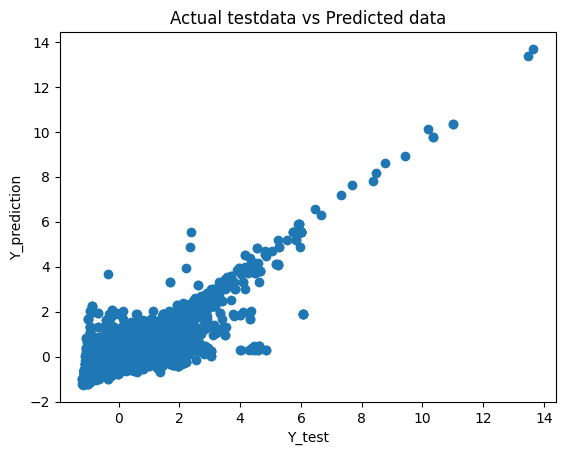

In [17]:
import matplotlib.pyplot as plt

plt.scatter(x=y_test, y=y_pred)
plt.xlabel("Y_test")
plt.ylabel("Y_prediction")
plt.title("Actual testdata vs Predicted data")
plt.show()

In [18]:
import pickle 
import os 

folder_path = "C:\Materials and it's Mechanical Properties\Model"
filename = "volume.pkl"
full_path = os.path.join(folder_path, filename)

with open(full_path, "wb") as file:
    pickle.dump(model,file,protocol=pickle.HIGHEST_PROTOCOL)

<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
C:\Users\kisho\AppData\Local\Temp\ipykernel_24732\2649798271.py:4: SyntaxWarning: invalid escape sequence '\M'
  folder_path = "C:\Materials and it's Mechanical Properties\Model"
